In [1]:
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks, peak_widths,resample,correlate, correlation_lags,peak_prominences,resample,butter, lfilter, freqz,medfilt
from matplotlib import rcParams
from scipy.stats import ttest_ind,ttest_rel,zscore


params = {
        "font.family" : "Arial",
        'pdf.fonttype' : 42,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'axes.linewidth': 0.5,
        'xtick.labelsize':9,
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'ytick.labelsize':9,
        'axes.spines.top':False,
        'axes.spines.right':False
         }
rcParams['figure.figsize'] = 21.7,8.27
rcParams.update(params)

def format_ax(ax,xlim,ylim,xspace,yspace):

    ax.set_xticks(np.arange(xlim[0],xlim[1]+ xspace,xspace))
    ax.set_yticks(np.arange(ylim[0],ylim[1]+ yspace,yspace))

    ax.set(ylim=(ylim[0], ylim[1]))
    ax.set(xlim=(xlim[0], xlim[1]))

In [2]:
### Function to align trials to event onsets, adapted from https://www.tdt.com/docs/sdk/offline-data-analysis/offline-data-python/examples/LickBouts/#time-filter-around-lick-bout-epocs
def trial_align(event_on,time,values,fps = 20,pre = 2, post = 10):
    TRANGE = [-pre*np.floor(fps), post*np.floor(fps)]

    trial_snips = []
    array_ind = []
    pre_stim = []
    post_stim = []

    for on in event_on:
        
            # If the bout cannot include pre-time seconds before event, make zero
        if on < pre:
            pass

        else: 
            # find first time index after bout onset
            array_ind.append(np.where(time > on)[0][0])
            # find index corresponding to pre and post stim durations
            pre_stim.append(array_ind[-1] + TRANGE[0])
            post_stim.append(array_ind[-1] + TRANGE[1])
            trial_snips.append(values[int(pre_stim[-1]):int(post_stim[-1])])
    
    # If some snippets are less than max length, add nans to end of array

    max1 = np.max([np.size(x) for x in trial_snips])
    for i,x in enumerate(trial_snips):
        if np.size(x) < max1:
            trial_snips[i] = np.concatenate((trial_snips[i],np.full((max1-np.size(trial_snips[i])), np.nan)))
    
    mean_trial_snips = np.mean(trial_snips, axis=0)
    peri_time = np.linspace(1, len(mean_trial_snips), len(mean_trial_snips))/fps - pre
    return trial_snips,peri_time

In [3]:
### Path to data. RENAME THIS TO YOUR PATH
base_dir = "/Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata"

In [4]:
### Functions to low pass filter pupil and face data

###low pass filter pupil
def filter_pupil(pupil,order = 1,cutoff = 1,fs = 20):
    def butter_lowpass(cutoff, fs, order=5):
        return butter(order, cutoff, fs=fs, btype='low', analog=False)

    def butter_lowpass_filter(data, cutoff, fs, order=5):
        b, a = butter_lowpass(cutoff, fs, order=order)
        y = lfilter(b, a, data)
        return y

    return butter_lowpass_filter(pupil, cutoff, fs, order)

###low pass filter face
def filter_face(face,order = 1,cutoff = 0.1,fs = 20):
    def butter_lowpass(cutoff, fs, order=5):
        return butter(order, cutoff, fs=fs, btype='low', analog=False)

    def butter_lowpass_filter(data, cutoff, fs, order=5):
        b, a = butter_lowpass(cutoff, fs, order=order)
        y = lfilter(b, a, data)
        return y

    return butter_lowpass_filter(face, cutoff, fs, order)

In [5]:
### Function to extract pupil dilation events

def get_pupil_events(id,date):
    id = id
    date = date
    face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
    path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
    df = pd.read_csv(path)
    pupil = np.array(df["Pupil Size"])
    time = np.array(df["Time"])
    speed = np.array(df["Running Speed"])
    speed[0] = 0
    dff = np.array(df["dFF"])
    face = np.array(pd.read_csv(face_path)["Facial Movement"])

    ###Onset detection alogrithm

    
    filter = filter_pupil(pupil) ###first apply low pass filter to pupil trace

    def groupSequence(x): 
        it = iter(x) 
        prev, res = next(it), [] 
    
        while prev is not None: 
            start = next(it, None) 
    
            if start and start > prev:

                res.append(prev) 
            elif res: 
                yield list(res + [prev]) 
                res = [] 
            prev = start 


    regions = list(groupSequence(filter))
    corrected_regions = [region for region in regions if len(region) >=15 ] ###only include regions that are >750ms
    corrected_regions = [region for region in corrected_regions if region[0]<np.median(filter) ] ###only include onsets that occur below z = median

    region_ix = [[np.where(filter == val)[0][0] for val in region] for region in corrected_regions] ### get indices for each region


    ##join regions that are near eachother
    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>20:
                if start-end<= 20:
                    #print(first[0]/20,second[0]/20)
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]


    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>10:
                if start-end<= 10:
                    #print(first[0]/20,second[0]/20)
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]
    onsets_ix = [region[0] for region in region_ix]


    ###get offsets and durations for pupil event
    offset_ix = []
    durations = []
    for i,(region,index) in enumerate(zip(corrected_regions,region_ix)):
        if i < len(region_ix)-1:
            start = index[-1] ###end of region
            end = region_ix[i+1][0] ### start of next region
            onset_y = region[0]
            offsets = np.where(filter[start:end] <= onset_y) ###find ix of first point that goes below onset 
        if len(offsets[0]) == 0: ###if it never goes below onset then use lowest value
            offset = start + np.argmin(filter[start:end])
        else:
            offset = start + offsets[0][0]


        offset_ix.append(offset)

        durations.append((offset-index[0])/20)

    ###handle last pupil event
    start = region_ix[-1][-1]
    end = 36000
    onset_y = corrected_regions[-1][0]
    offsets = np.where(filter[start:end] <= onset_y)
    if len(offsets[0]) == 0:
        offset = end-1
    else:
        offset = start + np.argmin(filter[start:end])

    offset_ix[-1] = offset

    durations[-1] = (offset-region_ix[-1][0])/20

    ###get pupil event amplitudes
    amplitudes = []
    amplitudes_ix = []
    for on,off in zip(onsets_ix,offset_ix):
        #print(on,off)
        amplitudes.append(max(filter[on:off])-filter[on])
        amplitudes_ix.append(on + np.argmax(filter[on:off]))

    ###get pupil event slopes
    slopes = []
    for region in corrected_regions:
        run = len(region)/20
        rise = region[-1]-region[0]
        slopes.append(rise/run)

    ###get dff data
    aucs = []
    peak_dffs = []
    mean_dffs = []
    for onset,offset in zip(onsets_ix,offset_ix):
        peak_dffs.append(max(dff[onset:offset]) - np.mean(dff[onset-30:onset]))
        aucs.append(np.trapz(dff[onset:offset]))
        mean_dffs.append(np.mean(dff[onset:offset])- np.mean(dff[onset-20:onset]))

    ###create dictionary

    events_dict = {"durations" :durations,
    "amplitudes": amplitudes,
    "slopes" : slopes,
    "onsets" : onsets_ix,
    "offsets" : offset_ix,
    "peak_ix" : amplitudes_ix,
    "ID" : [id] * len(durations),
    "Date" : [date] * len(durations),
    "peak_dff" : peak_dffs,
    "aucs" : aucs,
    "mean_dff" : mean_dffs,
    }
    
    return pd.DataFrame.from_dict(events_dict)

In [6]:
### Function to find locomotion and non-locomotion events
def contiguous_regions(condition):
    """Finds contiguous True regions of the boolean array "condition". Returns
    a 2D array where the first column is the start index of the region and the
    second column is the end index."""

    # Find the indicies of changes in "condition"
    d = np.diff(condition)
    idx, = d.nonzero() 

    # We need to start things after the change in "condition". Therefore, 
    # we'll shift the index by 1 to the right.
    idx += 1

    if condition[0]:
        # If the start of condition is True prepend a 0
        idx = np.r_[0, idx]

    if condition[-1]:
        # If the end of condition is True, append the length of the array
        idx = np.r_[idx, condition.size] # Edit

    # Reshape the result into two columns
    idx.shape = (-1,2)
    return idx


def get_movement_events(events,speed):
    onsets = [on for on in events["onsets"]] ###get pupil onsets ix
    offsets = [off for off in events["offsets"]] ###get pupil offsets ix
    events_ix = []
    for i,(on,off) in enumerate(zip(onsets,offsets)):
        if np.mean(speed[on:off]) >np.percentile(speed,65):
            events_ix.append(i)

    return events_ix
    
def get_quiet_events(events,speed):
    speed = abs(speed)
    onsets = [on for on in events["onsets"]] ###get pupil onsets ix
    offsets = [off for off in events["offsets"]] ###get pupil offsets ix
    events_ix = []
    for i,(on,off) in enumerate(zip(onsets,offsets)):
        if np.mean(speed[on:off]) <np.percentile(speed,45):
            events_ix.append(i)
     
    return events_ix


In [ ]:
### Get data for FigS5A

id_date = {
"004113":["20230808"],
"004114":["20230808","20230815"],
"004115":["20230804","20230808","20230815"],
"004116":["20230804","20230808","20230815"],
"004117":["20230804","20230808","20230815"],
"004118":["20230804","20230808","20230815"]
}

df_list = []
for id,dates in id_date.items():
    for date in dates:
    
        events = get_pupil_events(id,date)
  
        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = zscore((np.array(df["Running Speed"])))
        raw_speed = np.array(df["Running Speed"])

        onsets = [time[on]for on in events["onsets"]] ###get pupil onsets

     
        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])

        move_events = get_movement_events(events,raw_speed)
        quiet_events = get_quiet_events(events,raw_speed)

        dil_matrix,dil_times = trial_align(onsets,time,pupil,fps = 20,pre = 10, post = 10 )

        for j,trial in enumerate(dil_matrix):
            baseline = np.mean(trial[170:190])
            trial = trial-baseline
            if j in quiet_events:
                type = "quiet"
            elif j in move_events:
                type = "running"
            else:
                type = "neither"
            for i,Time in enumerate(dil_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Pupil","ID" : id, "Date": date,"Speed":type}
                df_list.append(new_dict)
                
        dff_matrix,dff_times = trial_align(onsets,time,dff,fps = 20,pre = 10, post = 10)
        for j,trial in enumerate(dff_matrix):
            baseline = np.mean(trial[170:190])
            trial = trial-baseline
            if j in quiet_events:
                type = "quiet"
            elif j in move_events:
                type = "running"
            else:
                type = "neither"
            for i,Time in enumerate(dff_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "dff","ID" : id, "Date": date,"Speed":type}
                df_list.append(new_dict)

        speed_matrix,speed_times = trial_align(onsets,time,speed,fps = 20,pre = 10, post = 10)

        for j,trial in enumerate(speed_matrix):
            baseline = np.mean(trial[170:190])
            trial = trial-baseline
            if j in move_events:
                type = "running"
            elif j in quiet_events:
                type = "quiet"
            else:
                type = "neither"
            for i,Time in enumerate(speed_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Speed","ID" : id, "Date": date,"Speed":type}
                df_list.append(new_dict)

align_df = pd.DataFrame.from_dict(df_list)
align_df = align_df.query("Speed != 'neither'")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10015/2650152756.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = align_df.groupby(["ID","Time from Onset (s)","type","Speed"]).mean().reset_index().query("type == 'dff'"), x = "Time from Onset (s)", y = "value", hue = "Speed",errorbar = "se",legend = None,linewidth = 1, palette= ["palegreen","darkgreen"])


Text(0, 0.5, '∆ F/F (z-scr)')

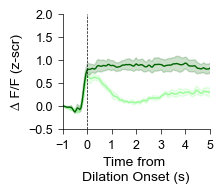

In [8]:
### Plot FigS5A
plt.figure(figsize = (1.9,1.5))

ax = sns.lineplot(data = align_df.groupby(["ID","Time from Onset (s)","type","Speed"]).mean().reset_index().query("type == 'dff'"), x = "Time from Onset (s)", y = "value", hue = "Speed",errorbar = "se",legend = None,linewidth = 1, palette= ["palegreen","darkgreen"])
format_ax(ax,(-1,5),(-0.5,2),1,0.5)
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)
ax.set_xlabel("Time from \nDilation Onset (s)")
ax.set_ylabel("∆ F/F (z-scr)")

In [9]:
### Get data for FigS5B

id_date = {
  "004113":["20230808"],
  "004114":["20230808","20230815"],
  "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}

df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_pupil_events(id,date)
        onsets = [on/20 for on in events["onsets"]] ###get pupil onsets
        offsets = [off/20 for off in events["offsets"]] ###get pupil offsets
        amplitudes = events["amplitudes"]
        peak_ix = events["peak_ix"]



        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = zscore((np.array(df["Running Speed"])))
        raw_speed = np.array(df["Running Speed"])

        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])

        move_events = get_movement_events(events,raw_speed)
        quiet_events = get_quiet_events(events,raw_speed)

        for event in list(range(0,len(onsets))):
            on = np.array(events["onsets"])[event]
            off = np.array(events["offsets"])[event]
        
            baseline = np.mean(dff[on - 40:on - 10])
            pre_dff = np.mean(dff[on-5:on]) - baseline
            during_dff = np.mean(dff[on:off]) - baseline

            if event in move_events:
                type = "Running"
            elif event in quiet_events:
                type = "Quiet"
            else:
                type = "neither"
            
            new_dict = { "trial" : event,"ID" : id, "Date": date,"type":type,"Pre Onset ∆ F/F":pre_dff,"∆ F/F": during_dff}

            df_list.append(new_dict)

df = pd.DataFrame.from_dict(df_list)
df = df.query("type != 'neither'")


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10015/2533950902.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "∆ F/F",errorbar = "se",fill = None,errwidth= 1)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10015/2533950902.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "∆ F/F",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)


[(0.0, 0.75)]

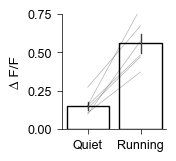

In [10]:
### Plot FigS5B

plt.figure(figsize = (1.35,1.5))
g = sns.barplot(data = df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "∆ F/F",errorbar = "se",fill = None,errwidth= 1)
sns.lineplot(data = df.groupby(["ID",'type']).mean().reset_index(), x = "type", y = "∆ F/F",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
g.xaxis.label.set_visible(False)
g.set_yticks(np.arange(0,1,0.25))
g.set(ylim=(0,0.75))

In [11]:
### Get data for FigS5C

id_date = {
"004113":["20230808"],
"004114":["20230808","20230815"],
"004115":["20230804","20230808","20230815"],
"004116":["20230804","20230808","20230815"],
"004117":["20230804","20230808","20230815"],
"004118":["20230804","20230808","20230815"]
}

df_list = []
for id,dates in id_date.items():
    for date in dates:
    
        events = get_pupil_events(id,date)
        onsets = [on/20 for on in events["onsets"]] ###get pupil onsets
        amplitudes = events["amplitudes"]

  
        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = zscore((np.array(df["Running Speed"])))
        raw_speed = np.array(df["Running Speed"])
     
        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])

        move_events = get_movement_events(events,raw_speed)
        quiet_events = get_quiet_events(events,raw_speed)
        quiet_amps = []
        for i,amp in enumerate(amplitudes):
            if i in quiet_events:
                quiet_amps.append(amp)
        binned_amps = np.array(pd.qcut(quiet_amps,q = 2 ,labels = ["1","2"]))

        quiet_onsets = np.array(onsets)[np.array(quiet_events)]

        dil_matrix,dil_times = trial_align(quiet_onsets,time,pupil,fps = 20,pre = 10, post = 10 )

        for j,trial in enumerate(dil_matrix):
            baseline = np.mean(trial[170:190])
            trial = trial-baseline
            for i,Time in enumerate(dil_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Pupil","ID" : id, "Date": date,"bin":binned_amps[j]}
                df_list.append(new_dict)
                
        dff_matrix,dff_times = trial_align(quiet_onsets,time,dff,fps = 20,pre = 10, post = 10)
        for j,trial in enumerate(dff_matrix):
            baseline = np.mean(trial[170:190])
            trial = trial-baseline
            if j in quiet_events:
                type = "quiet"
            elif j in move_events:
                type = "running"
            else:
                type = "neither"
            for i,Time in enumerate(dff_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "dff","ID" : id, "Date": date,"bin":binned_amps[j]}
                df_list.append(new_dict)

        speed_matrix,speed_times = trial_align(quiet_onsets,time,speed,fps = 20,pre = 10, post = 10)

        for j,trial in enumerate(speed_matrix):
            baseline = np.mean(trial[170:190])
            trial = trial-baseline
            if j in move_events:
                type = "running"
            elif j in quiet_events:
                type = "quiet"
            else:
                type = "neither"
            for i,Time in enumerate(speed_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Speed","ID" : id, "Date": date,"bin":binned_amps[j]}
                df_list.append(new_dict)
        
        face_matrix,face_times = trial_align(quiet_onsets,time,face,fps = 20,pre = 10, post = 10)

        for j,trial in enumerate(face_matrix):
            baseline = np.mean(trial[170:190])
            trial = trial-baseline
            if j in move_events:
                type = "running"
            elif j in quiet_events:
                type = "quiet"
            else:
                type = "neither"
            for i,Time in enumerate(speed_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Face","ID" : id, "Date": date,"bin":binned_amps[j]}
                df_list.append(new_dict)

quiet_align_df = pd.DataFrame.from_dict(df_list)


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10015/2617202389.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = quiet_align_df.groupby(["ID","Time from Onset (s)","type","bin"]).mean().reset_index().query("type == 'Pupil'"), x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "bin",palette= ["cornflowerblue","darkblue"],legend = None,linewidth = 1)


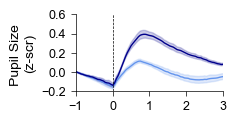

In [13]:
### Plot FigS5C (Top)
plt.figure(figsize = (1.9,1))
ax = sns.lineplot(data = quiet_align_df.groupby(["ID","Time from Onset (s)","type","bin"]).mean().reset_index().query("type == 'Pupil'"), x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "bin",palette= ["cornflowerblue","darkblue"],legend = None,linewidth = 1)
ax.xaxis.label.set_visible(False)
ax.set_ylabel("Pupil Size \n(z-scr)")
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)
format_ax(ax,(-1,3),(-0.2,0.6),1,0.2)



/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10015/1885811020.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = quiet_align_df.groupby(["ID","Time from Onset (s)","type","bin"]).mean().reset_index().query("type == 'dff'") ,x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "bin",palette= ["palegreen","darkgreen"],legend = None,linewidth = 1)


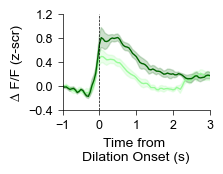

In [ ]:
### Plot FigS5C (Bottom)

plt.figure(figsize = (1.9,1.25))
ax = sns.lineplot(data = quiet_align_df.groupby(["ID","Time from Onset (s)","type","bin"]).mean().reset_index().query("type == 'dff'") ,x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "bin",palette= ["palegreen","darkgreen"],legend = None,linewidth = 1)
ax.set_xlabel("Time from \nDilation Onset (s)")
ax.set_ylabel("∆ F/F (z-scr)")
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)
format_ax(ax,(-1,3),(-0.4,1.2),1,0.4)

In [18]:
### Get data for FigS5D

id_date = {
  "004113":["20230808"],
  "004114":["20230808","20230815"],
  "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}

df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_pupil_events(id,date)
        onsets = [on/20 for on in events["onsets"]] ###get pupil onsets
        offsets = [off/20 for off in events["offsets"]] ###get pupil offsets
        amplitudes = events["amplitudes"]
        peak_ix = events["peak_ix"]



        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = zscore((np.array(df["Running Speed"])))
        raw_speed = np.array(df["Running Speed"])

        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])

        move_events = get_movement_events(events,raw_speed)
        quiet_events = get_quiet_events(events,raw_speed)
        quiet_amps = []
        for i,amp in enumerate(amplitudes):
            if i in quiet_events:
                quiet_amps.append(amp)
        binned_amps = np.array(pd.qcut(quiet_amps,q = 2 ,labels = ["1","2"]))



        
        for i,event in enumerate(quiet_events):
            on = np.array(events["onsets"])[event]
            off = np.array(events["offsets"])[event]
            baseline = np.mean(dff[on - 40:on - 10])
            pre_dff = np.mean(dff[on-5:on]) - baseline
            during_dff = np.mean(dff[on:off]) - baseline
            during_speed = np.mean(raw_speed[on:off])
            new_dict = { "trial" : event,"ID" : id, "Date": date,"Pre Onset ∆ F/F":pre_dff,"∆ F/F": during_dff,"amp_bin":binned_amps[i],"speed":during_speed,"amplitude":quiet_amps[i]}
            df_list.append(new_dict)

quiet_bar_df = pd.DataFrame.from_dict(df_list)


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10015/283861430.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = quiet_bar_df.groupby(["ID",'amp_bin']).mean().reset_index(), x = "amp_bin", y = "∆ F/F",errorbar = "se",fill = None,errwidth= 1)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10015/283861430.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = quiet_bar_df.groupby(["ID",'amp_bin']).mean().reset_index(), x = "amp_bin", y = "∆ F/F",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)


[Text(0, 0, 'Low'), Text(1, 0, 'High')]

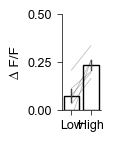

In [21]:
### Plot FigS5D (Left)
plt.figure(figsize = (0.5,1.25))
g = sns.barplot(data = quiet_bar_df.groupby(["ID",'amp_bin']).mean().reset_index(), x = "amp_bin", y = "∆ F/F",errorbar = "se",fill = None,errwidth= 1)
sns.lineplot(data = quiet_bar_df.groupby(["ID",'amp_bin']).mean().reset_index(), x = "amp_bin", y = "∆ F/F",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
g.set_xlabel("Pupil Amplitude\n Median")
g.set_yticks(np.arange(0,0.75,0.25))
g.set(ylim=(0,0.5))
g.xaxis.label.set_visible(False)
labels = ["Low","High"]
g.set_xticklabels(labels)


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10015/3845370563.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = quiet_bar_df.groupby(["ID",'amp_bin']).mean().reset_index(), x = "amp_bin", y = "speed",errorbar = "se",fill = None,errwidth= 1)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10015/3845370563.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = quiet_bar_df.groupby(["ID",'amp_bin']).mean().reset_index(), x = "amp_bin", y = "speed",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)


[Text(0, 0, 'Low'), Text(1, 0, 'High')]

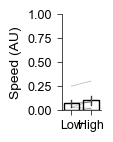

In [20]:
### Plot FigS5D (Left)
plt.figure(figsize = (0.5,1.25))
g = sns.barplot(data = quiet_bar_df.groupby(["ID",'amp_bin']).mean().reset_index(), x = "amp_bin", y = "speed",errorbar = "se",fill = None,errwidth= 1)
sns.lineplot(data = quiet_bar_df.groupby(["ID",'amp_bin']).mean().reset_index(), x = "amp_bin", y = "speed",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)

g.set_xlabel("Pupil Amplitude\n Quartile")
g.set_ylabel("Speed (AU)")

g.set_yticks(np.arange(0,1.25,0.25))
g.set(ylim=(0,1))
g.xaxis.label.set_visible(False)
labels = ["Low","High"]
g.set_xticklabels(labels)

In [22]:
### Get data for FigS5E

id_date = {
  #"004113":["20230808"],
  "004114":["20230808","20230815"],
"004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}

df_list = []
for id,dates in id_date.items():
    for date in dates:
    
        events = get_pupil_events(id,date)
        onsets = [on/20 for on in events["onsets"]] ###get pupil onsets
        amplitudes = events["amplitudes"]

  
        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = zscore((np.array(df["Running Speed"])))
        raw_speed = np.array(df["Running Speed"])
     
        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])

        move_events = get_movement_events(events,raw_speed)
        quiet_events = get_quiet_events(events,raw_speed)
        
        move_amps = []
        for i,amp in enumerate(amplitudes):
            if i in move_events:
                move_amps.append(amp)
        binned_amps = np.array(pd.qcut(move_amps,q = 2 ,labels = ["1","2"]))

        move_onsets = np.array(onsets)[np.array(move_events)]

        dil_matrix,dil_times = trial_align(move_onsets,time,pupil,fps = 20,pre = 10, post = 10 )

        for j,trial in enumerate(dil_matrix):
            baseline = np.mean(trial[170:190])
            trial = trial-baseline
            for i,Time in enumerate(dil_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Pupil","ID" : id, "Date": date,"bin":binned_amps[j]}
                df_list.append(new_dict)
                
        dff_matrix,dff_times = trial_align(move_onsets,time,dff,fps = 20,pre = 10, post = 10)
        for j,trial in enumerate(dff_matrix):
            baseline = np.mean(trial[170:190])
            trial = trial-baseline
            if j in quiet_events:
                type = "quiet"
            elif j in move_events:
                type = "running"
            else:
                type = "neither"
            for i,Time in enumerate(dff_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "dff","ID" : id, "Date": date,"bin":binned_amps[j]}
                df_list.append(new_dict)

        speed_matrix,speed_times = trial_align(move_onsets,time,speed,fps = 20,pre = 10, post = 10)

        for j,trial in enumerate(speed_matrix):
            baseline = np.mean(trial[170:190])
            trial = trial-baseline
            if j in move_events:
                type = "running"
            elif j in quiet_events:
                type = "quiet"
            else:
                type = "neither"
            for i,Time in enumerate(speed_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Speed","ID" : id, "Date": date,"bin":binned_amps[j]}
                df_list.append(new_dict)

            
        face_matrix,face_times = trial_align(move_onsets,time,face,fps = 20,pre = 10, post = 10)

        for j,trial in enumerate(face_matrix):
            baseline = np.mean(trial[170:190])
            trial = trial-baseline
            if j in move_events:
                type = "running"
            elif j in quiet_events:
                type = "quiet"
            else:
                type = "neither"
            for i,Time in enumerate(speed_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Face","ID" : id, "Date": date,"bin":binned_amps[j]}
                df_list.append(new_dict)

run_align_df = pd.DataFrame.from_dict(df_list)


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10015/2346313468.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = run_align_df.groupby(["ID","Time from Onset (s)","type","bin"]).mean().reset_index().query("type == 'Pupil'"), x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "bin",palette= ["cornflowerblue","darkblue"],legend = None,linewidth = 1)


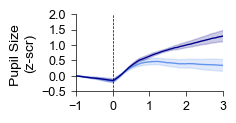

In [ ]:
### Plot FigS5E (Top)
plt.figure(figsize = (1.9,1))
ax = sns.lineplot(data = run_align_df.groupby(["ID","Time from Onset (s)","type","bin"]).mean().reset_index().query("type == 'Pupil'"), x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "bin",palette= ["cornflowerblue","darkblue"],legend = None,linewidth = 1)
ax.xaxis.label.set_visible(False)
ax.set_ylabel("Pupil Size \n(z-scr)")
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)
format_ax(ax,(-1,3),(-0.5,2),1,0.5)



/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10015/2879996152.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = run_align_df.groupby(["ID","Time from Onset (s)","type","bin"]).mean().reset_index().query("type == 'dff'") ,x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "bin",palette= ["palegreen","darkgreen"],legend = None,linewidth = 1)


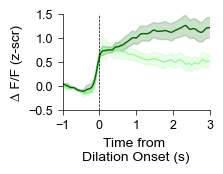

In [ ]:
### Plot FigS5E (Bottom)
plt.figure(figsize = (1.9,1.25))
ax = sns.lineplot(data = run_align_df.groupby(["ID","Time from Onset (s)","type","bin"]).mean().reset_index().query("type == 'dff'") ,x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "bin",palette= ["palegreen","darkgreen"],legend = None,linewidth = 1)
ax.set_xlabel("Time from \nDilation Onset (s)")
ax.set_ylabel("∆ F/F (z-scr)")
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)
format_ax(ax,(-1,3),(-0.5,1.5),1,0.5)

In [25]:
### Get data for FigS5F

id_date = {
  #"004113":["20230808"],
  "004114":["20230808","20230815"],
  "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}

df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_pupil_events(id,date)
        onsets = [on/20 for on in events["onsets"]] ###get pupil onsets
        offsets = [off/20 for off in events["offsets"]] ###get pupil offsets
        amplitudes = events["amplitudes"]
        peak_ix = events["peak_ix"]



        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = zscore((np.array(df["Running Speed"])))
        raw_speed = np.array(df["Running Speed"])

        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])

        move_events = get_movement_events(events,raw_speed)
        quiet_events = get_quiet_events(events,raw_speed)
        move_amps = []
        for i,amp in enumerate(amplitudes):
            if i in move_events:
                move_amps.append(amp)
        binned_amps = np.array(pd.qcut(move_amps,q = 2 ,labels = ["1","2"]))



        
        for i,event in enumerate(move_events):
            on = np.array(events["onsets"])[event]
            off = np.array(events["offsets"])[event]
            baseline = np.mean(dff[on - 40:on - 10])
            pre_dff = np.mean(dff[on-5:on]) - baseline
            during_dff = np.mean(dff[on:off]) - baseline
            during_speed = np.mean(raw_speed[on:off])
            new_dict = { "trial" : event,"ID" : id, "Date": date,"Pre Onset ∆ F/F":pre_dff,"∆ F/F": during_dff,"amp_bin":binned_amps[i],"speed":during_speed,"amplitude":move_amps[i]}
            df_list.append(new_dict)

 

df = pd.DataFrame.from_dict(df_list)


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10015/3132614603.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = df.groupby(["ID",'amp_bin']).mean().reset_index(), x = "amp_bin", y = "∆ F/F",errorbar = "se",fill = None,errwidth= 1)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10015/3132614603.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = df.groupby(["ID",'amp_bin']).mean().reset_index(), x = "amp_bin", y = "∆ F/F",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)


[Text(0, 0, 'Low'), Text(1, 0, 'High')]

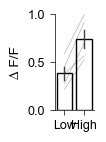

In [26]:
### Plot FigS5F (Left)
plt.figure(figsize = (0.5,1.25))
g = sns.barplot(data = df.groupby(["ID",'amp_bin']).mean().reset_index(), x = "amp_bin", y = "∆ F/F",errorbar = "se",fill = None,errwidth= 1)
sns.lineplot(data = df.groupby(["ID",'amp_bin']).mean().reset_index(), x = "amp_bin", y = "∆ F/F",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)

g.set_xlabel("Pupil Amplitude\n Quartile")
g.set_yticks(np.arange(0,2,0.5))
g.set(ylim=(0,1))
g.xaxis.label.set_visible(False)
labels = ["Low","High"]
g.set_xticklabels(labels)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10015/4047311663.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = df.groupby(["ID",'amp_bin']).mean().reset_index(), x = "amp_bin", y = "speed",errorbar = "se",fill = None,errwidth= 1)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10015/4047311663.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = df.groupby(["ID",'amp_bin']).mean().reset_index(), x = "amp_bin", y = "speed",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)


[Text(0, 0, 'Low'), Text(1, 0, 'High')]

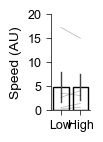

In [27]:
### Plot FigS5F (Right)

plt.figure(figsize = (0.5,1.25))
g = sns.barplot(data = df.groupby(["ID",'amp_bin']).mean().reset_index(), x = "amp_bin", y = "speed",errorbar = "se",fill = None,errwidth= 1)
sns.lineplot(data = df.groupby(["ID",'amp_bin']).mean().reset_index(), x = "amp_bin", y = "speed",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)

g.set_xlabel("Pupil Amplitude\n Quartile")
g.set_ylabel("Speed (AU)")

g.set_yticks(np.arange(0,25,5))
g.set(ylim=(0,20))
g.xaxis.label.set_visible(False)
labels = ["Low","High"]
g.set_xticklabels(labels)